# Step 1: Khám phá Dữ liệu MVTec AD (Bottle Category)

Notebook này giúp bạn:
1. Tìm hiểu cấu trúc tập dữ liệu **MVTec Anomaly Detection**.
2. Kiểm tra `MVTecDataset` và `DataLoader` viết bằng PyTorch.
3. Trực quan hóa các dạng lỗi (*broken_large*, *broken_small*, *contamination*) cùng Ground-Truth Mask.
4. Hiểu về các lưu ý quan trọng khi Data Augmentation trong bài toán Visual Anomaly Detection.

In [1]:
import sys
from pathlib import Path

# Thêm root folder vào sys.path để import từ src
sys.path.append(str(Path("..").resolve()))

import torch
import matplotlib.pyplot as plt
from src.data import MVTecDataset, get_mvtec_dataloader
from src.utils import denormalize, overlay_mask_on_image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.6.0+cu124
CUDA available: True


## 1. Khởi tạo Dataset

In [2]:
DATA_DIR = "../data"
CATEGORY = "bottle"

# Tập Train chỉ chứa ảnh 'good' (Normal)
train_ds = MVTecDataset(root_dir=DATA_DIR, category=CATEGORY, split="train")

# Tập Test chứa cả ảnh 'good' lẫn các ảnh có khuyết tật
test_ds = MVTecDataset(root_dir=DATA_DIR, category=CATEGORY, split="test")

print(f"Số lượng ảnh Train (toàn bộ là Normal): {len(train_ds)}")
print(f"Số lượng ảnh Test (Normal + Anomaly):   {len(test_ds)}")

Số lượng ảnh Train (toàn bộ là Normal): 209
Số lượng ảnh Test (Normal + Anomaly):   83


## 2. Thống kê chi tiết các loại lỗi trong Test set

In [3]:
breakdown = {}
for s in test_ds.samples:
    dtype = s["defect_type"]
    breakdown[dtype] = breakdown.get(dtype, 0) + 1

for dtype, count in breakdown.items():
    status = "[Normal] " if dtype == "good" else "[Anomaly]"
    print(f"{status} {dtype:15s}: {count:2d} ảnh")

[Anomaly] broken_large   : 20 ảnh
[Anomaly] broken_small   : 22 ảnh
[Anomaly] contamination  : 21 ảnh
[Normal]  good           : 20 ảnh


## 3. Trực quan hóa ảnh lỗi và Ground-Truth Mask

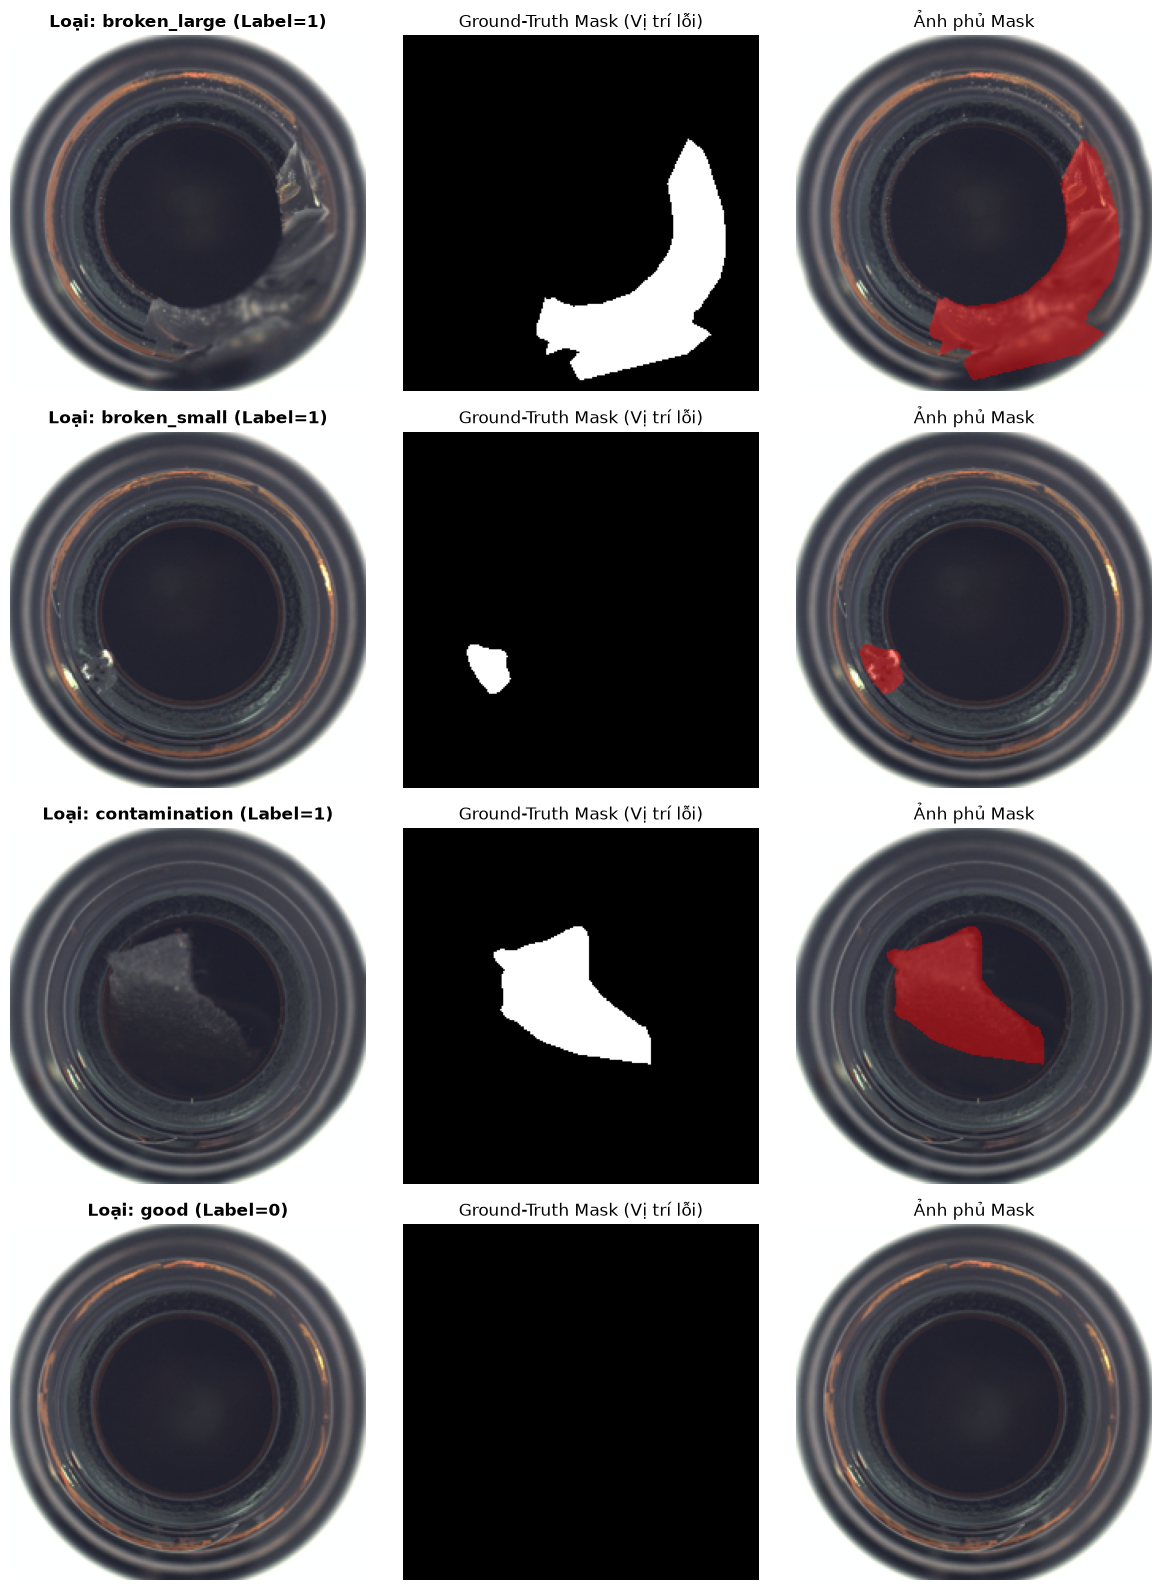

In [4]:
# Tìm index mẫu đại diện cho từng loại defect
defect_indices = {}
for idx, s in enumerate(test_ds.samples):
    dtype = s["defect_type"]
    if dtype not in defect_indices:
        defect_indices[dtype] = idx

fig, axes = plt.subplots(len(defect_indices), 3, figsize=(12, 4 * len(defect_indices)))

for row, (dtype, sample_idx) in enumerate(defect_indices.items()):
    item = test_ds[sample_idx]
    img = denormalize(item["image"])
    mask = item["mask"].squeeze().cpu().numpy()
    overlay = overlay_mask_on_image(img, mask, alpha=0.45)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Loại: {dtype} (Label={item['label']})", fontsize=12, fontweight="bold")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Ground-Truth Mask (Vị trí lỗi)", fontsize=12)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Ảnh phủ Mask", fontsize=12)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## 4. Kiểm tra Batch Loader

In [5]:
loader = get_mvtec_dataloader(root_dir=DATA_DIR, category=CATEGORY, split="train", batch_size=8)
batch = next(iter(loader))

print("Shape tensor ảnh: ", batch["image"].shape)  # [B, 3, 224, 224]
print("Shape tensor mask: ", batch["mask"].shape)   # [B, 1, 224, 224]
print("Shape nhãn:        ", batch["label"].shape)  # [B]
print("Danh sách nhãn:   ", batch["label"].tolist())

Shape tensor ảnh:  torch.Size([8, 3, 224, 224])
Shape tensor mask:  torch.Size([8, 1, 224, 224])
Shape nhãn:         torch.Size([8])
Danh sách nhãn:    [0, 0, 0, 0, 0, 0, 0, 0]
